In [2]:
# Model Development

## Training-Only Feature Selection and Ridge Hyperparameter Tuning

This notebook develops the one-month-ahead forecasting model using chronologically separated training and validation periods.

The workflow includes:

1. loading the leakage-free forecasting dataset created in Notebook 03;
2. defining chronological training, validation, and test periods;
3. ranking candidate predictors using training data only;
4. evaluating alternative feature-set sizes on the validation period;
5. selecting the optimal number of predictors;
6. tuning the Ridge Regression regularization parameter using validation performance only; and
7. freezing the final model specification before independent testing.

The independent 2024–2025 test period is not used for feature selection or hyperparameter tuning.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3577235965.py, line 9)

In [3]:
# ============================================================
# LOAD LEAKAGE-FREE MODELING DATASET
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project data directory."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODELING_FILE = (
    PROCESSED_DIR /
    "mnjoli_water_stress_modeling_dataset.csv"
)


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df_model = pd.read_csv(
    MODELING_FILE,
    parse_dates=[
        "month_date",
        "forecast_date"
    ]
)

df_model = (
    df_model
    .sort_values("forecast_date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------

print("=" * 70)
print("LEAKAGE-FREE MODELING DATASET")
print("=" * 70)

print(
    "Shape:",
    df_model.shape
)

print(
    "Forecast period:",
    df_model["forecast_date"].min(),
    "to",
    df_model["forecast_date"].max()
)

print(
    "Missing values:",
    df_model.isna().sum().sum()
)

print(
    "Duplicate forecast dates:",
    df_model["forecast_date"]
    .duplicated()
    .sum()
)

LEAKAGE-FREE MODELING DATASET
Shape: (126, 62)
Forecast period: 2015-07-01 00:00:00 to 2025-12-01 00:00:00
Missing values: 0
Duplicate forecast dates: 0


In [4]:
# ============================================================
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

TARGET = "target_t_plus_1"

TRAIN_END = pd.Timestamp("2021-12-01")
VALIDATION_END = pd.Timestamp("2023-12-01")


# ------------------------------------------------------------
# IDENTIFY PREDICTORS
# ------------------------------------------------------------

non_predictors = [
    "month_date",
    "forecast_date",
    TARGET
]

predictor_columns = [
    col
    for col in df_model.columns
    if col not in non_predictors
]


# ------------------------------------------------------------
# CREATE PERIOD MASKS
# ------------------------------------------------------------

train_mask = (
    df_model["forecast_date"]
    <= TRAIN_END
)

validation_mask = (
    (df_model["forecast_date"] > TRAIN_END)
    &
    (df_model["forecast_date"] <= VALIDATION_END)
)

test_mask = (
    df_model["forecast_date"]
    > VALIDATION_END
)


# ------------------------------------------------------------
# CREATE SPLITS
# ------------------------------------------------------------

X_train_full = (
    df_model.loc[
        train_mask,
        predictor_columns
    ]
    .copy()
)

y_train = (
    df_model.loc[
        train_mask,
        TARGET
    ]
    .copy()
)

X_val_full = (
    df_model.loc[
        validation_mask,
        predictor_columns
    ]
    .copy()
)

y_val = (
    df_model.loc[
        validation_mask,
        TARGET
    ]
    .copy()
)

X_test_full = (
    df_model.loc[
        test_mask,
        predictor_columns
    ]
    .copy()
)

y_test = (
    df_model.loc[
        test_mask,
        TARGET
    ]
    .copy()
)


# ------------------------------------------------------------
# VERIFY PERIODS
# ------------------------------------------------------------

print("=" * 70)
print("CHRONOLOGICAL SPLIT")
print("=" * 70)

print("\nTraining:")
print("Observations:", len(X_train_full))
print(
    "Forecast period:",
    df_model.loc[
        train_mask,
        "forecast_date"
    ].min(),
    "to",
    df_model.loc[
        train_mask,
        "forecast_date"
    ].max()
)

print("\nValidation:")
print("Observations:", len(X_val_full))
print(
    "Forecast period:",
    df_model.loc[
        validation_mask,
        "forecast_date"
    ].min(),
    "to",
    df_model.loc[
        validation_mask,
        "forecast_date"
    ].max()
)

print("\nTest:")
print("Observations:", len(X_test_full))
print(
    "Forecast period:",
    df_model.loc[
        test_mask,
        "forecast_date"
    ].min(),
    "to",
    df_model.loc[
        test_mask,
        "forecast_date"
    ].max()
)

print("\nPredictors:", len(predictor_columns))

print(
    "Training missing values:",
    X_train_full.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_val_full.isna().sum().sum()
)

print(
    "Test missing values:",
    X_test_full.isna().sum().sum()
)

CHRONOLOGICAL SPLIT

Training:
Observations: 78
Forecast period: 2015-07-01 00:00:00 to 2021-12-01 00:00:00

Validation:
Observations: 24
Forecast period: 2022-01-01 00:00:00 to 2023-12-01 00:00:00

Test:
Observations: 24
Forecast period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00

Predictors: 59
Training missing values: 0
Validation missing values: 0
Test missing values: 0


In [5]:
# ============================================================
# TRAINING-ONLY FEATURE RANKING
# ============================================================

# IMPORTANT:
# Feature ranking is calculated exclusively from the training
# period. Validation and test observations play no role in
# determining feature importance or feature selection.


# ------------------------------------------------------------
# 1. COMBINE TRAINING PREDICTORS AND TARGET
# ------------------------------------------------------------

training_data = (
    X_train_full
    .copy()
)

training_data[TARGET] = (
    y_train.values
)


# ------------------------------------------------------------
# 2. CALCULATE TRAINING-ONLY CORRELATIONS
# ------------------------------------------------------------

feature_correlations = (
    training_data
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
)

absolute_correlations = (
    feature_correlations
    .abs()
    .sort_values(ascending=False)
)


# ------------------------------------------------------------
# 3. CREATE RANKING TABLE
# ------------------------------------------------------------

feature_ranking = pd.DataFrame({
    "Feature": absolute_correlations.index,
    "Correlation": [
        feature_correlations[feature]
        for feature in absolute_correlations.index
    ],
    "Absolute_Correlation": absolute_correlations.values
})

feature_ranking.insert(
    0,
    "Rank",
    range(
        1,
        len(feature_ranking) + 1
    )
)


# ------------------------------------------------------------
# 4. DISPLAY TOP 20
# ------------------------------------------------------------

print("=" * 70)
print("TOP 20 TRAINING-ONLY FEATURES")
print("=" * 70)

print(
    feature_ranking
    .head(20)
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. VERIFY RANKING SOURCE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE-SELECTION VERIFICATION")
print("=" * 70)

print(
    "Training observations used:",
    len(X_train_full)
)

print(
    "Candidate predictors ranked:",
    len(feature_ranking)
)

print(
    "Validation observations used for ranking: 0"
)

print(
    "Test observations used for ranking: 0"
)


# ------------------------------------------------------------
# 6. SAVE RANKED FEATURE NAMES
# ------------------------------------------------------------

ranked_features = (
    feature_ranking["Feature"]
    .tolist()
)

assert len(ranked_features) == len(
    predictor_columns
), "Not all predictors were ranked."

assert set(ranked_features) == set(
    predictor_columns
), "Feature ranking does not match predictor set."

print(
    "\nPASS — all candidate predictors were ranked "
    "using training data only."
)

TOP 20 TRAINING-ONLY FEATURES
 Rank                   Feature  Correlation  Absolute_Correlation
    1 soil_moisture_layer1_lag1       0.3210                0.3210
    2     precipitation_mm_lag1       0.3092                0.3092
    3                    pet_mm      -0.2947                0.2947
    4 soil_moisture_layer2_lag1       0.2794                0.2794
    5          precipitation_mm       0.2734                0.2734
    6      soil_moisture_layer2       0.2733                0.2733
    7      precipitation_3month       0.2707                0.2707
    8      soil_moisture_layer1       0.2522                0.2522
    9               pet_mm_lag1      -0.2431                0.2431
   10         temperature_max_c      -0.2382                0.2382
   11    surface_runoff_mm_lag1       0.2348                0.2348
   12            runoff_mm_lag1       0.2261                0.2261
   13                pet_3month      -0.2243                0.2243
   14           solar_radiation 

In [6]:
# ============================================================
# FEATURE-COUNT SELECTION USING VALIDATION DATA
# ============================================================

# Feature rankings were determined from training data only.
# The validation period is now used to determine how many of
# those ranked predictors should be retained.
#
# The independent test period remains completely untouched.


# ------------------------------------------------------------
# 1. DEFINE CANDIDATE FEATURE COUNTS
# ------------------------------------------------------------

feature_counts = [
    5,
    10,
    15,
    20,
    30,
    40,
    50
]

feature_count_results = []


# ------------------------------------------------------------
# 2. EVALUATE EACH FEATURE COUNT
# ------------------------------------------------------------

for n_features in feature_counts:

    selected_features = (
        ranked_features[
            :min(
                n_features,
                len(ranked_features)
            )
        ]
    )

    X_train_selected = (
        X_train_full[
            selected_features
        ]
    )

    X_val_selected = (
        X_val_full[
            selected_features
        ]
    )

    # --------------------------------------------------------
    # Ridge pipeline
    # --------------------------------------------------------
    # alpha=1.0 is held constant during feature-count
    # selection. Regularization strength will be tuned only
    # after the optimal number of predictors is identified.
    # --------------------------------------------------------

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(
                alpha=1.0
            )
        )
    ])

    model.fit(
        X_train_selected,
        y_train
    )

    validation_predictions = (
        model.predict(
            X_val_selected
        )
    )


    # --------------------------------------------------------
    # PERFORMANCE METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_val,
        validation_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            validation_predictions
        )
    )

    r2 = r2_score(
        y_val,
        validation_predictions
    )


    feature_count_results.append({
        "Features": len(selected_features),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# ------------------------------------------------------------
# 3. CREATE RESULTS TABLE
# ------------------------------------------------------------

feature_count_results_df = (
    pd.DataFrame(
        feature_count_results
    )
)


# ------------------------------------------------------------
# 4. DISPLAY RESULTS SORTED BY RMSE
# ------------------------------------------------------------

print("=" * 70)
print("VALIDATION FEATURE-COUNT COMPARISON")
print("=" * 70)

print(
    feature_count_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. SELECT BEST FEATURE COUNT
# ------------------------------------------------------------

best_feature_row = (
    feature_count_results_df
    .loc[
        feature_count_results_df[
            "RMSE"
        ].idxmin()
    ]
)

best_n_features = int(
    best_feature_row[
        "Features"
    ]
)

selected_features = (
    ranked_features[
        :best_n_features
    ]
)


# ------------------------------------------------------------
# 6. REPORT SELECTION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SELECTED FEATURE COUNT")
print("=" * 70)

print(
    "Optimal number of features:",
    best_n_features
)

print(
    "Validation MAE:",
    round(
        best_feature_row["MAE"],
        4
    )
)

print(
    "Validation RMSE:",
    round(
        best_feature_row["RMSE"],
        4
    )
)

print(
    "Validation R²:",
    round(
        best_feature_row["R2"],
        4
    )
)


# ------------------------------------------------------------
# 7. DISPLAY SELECTED FEATURES
# ------------------------------------------------------------

print("\nSelected predictors:")

for i, feature in enumerate(
    selected_features,
    start=1
):
    print(
        f"{i:02d}. {feature}"
    )


# ------------------------------------------------------------
# 8. VERIFY TEST SET HAS NOT PARTICIPATED
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST-SET ISOLATION")
print("=" * 70)

print(
    "Training observations used for model fitting:",
    len(X_train_full)
)

print(
    "Validation observations used for selection:",
    len(X_val_full)
)

print(
    "Test observations used for selection: 0"
)

print(
    "\nPASS — independent test data were not used "
    "for feature-count selection."
)

VALIDATION FEATURE-COUNT COMPARISON
 Features    MAE   RMSE      R2
       15 0.9645 1.3234  0.2404
       10 1.0335 1.3536  0.2054
       20 1.0220 1.3703  0.1857
       30 1.0221 1.4044  0.1446
       50 1.0849 1.4862  0.0421
       40 1.1182 1.5062  0.0161
        5 1.1817 1.5226 -0.0055

SELECTED FEATURE COUNT
Optimal number of features: 15
Validation MAE: 0.9645
Validation RMSE: 1.3234
Validation R²: 0.2404

Selected predictors:
01. soil_moisture_layer1_lag1
02. precipitation_mm_lag1
03. pet_mm
04. soil_moisture_layer2_lag1
05. precipitation_mm
06. soil_moisture_layer2
07. precipitation_3month
08. soil_moisture_layer1
09. pet_mm_lag1
10. temperature_max_c
11. surface_runoff_mm_lag1
12. runoff_mm_lag1
13. pet_3month
14. solar_radiation
15. solar_radiation_lag1

TEST-SET ISOLATION
Training observations used for model fitting: 78
Validation observations used for selection: 24
Test observations used for selection: 0

PASS — independent test data were not used for feature-count selecti

In [7]:
# ============================================================
# RIDGE HYPERPARAMETER TUNING
# ============================================================

# The optimal feature count has already been determined using
# the validation period. The selected 15 predictors are now
# held fixed while the Ridge regularization parameter (alpha)
# is tuned.
#
# The independent 2024-2025 test period remains untouched.


# ------------------------------------------------------------
# 1. DEFINE ALPHA SEARCH SPACE
# ------------------------------------------------------------

alpha_values = [
    0.01,
    0.05,
    0.10,
    0.50,
    1.00,
    2.00,
    5.00,
    10.00,
    20.00,
    50.00,
    100.00
]


# ------------------------------------------------------------
# 2. SELECT THE FIXED 15-FEATURE MATRICES
# ------------------------------------------------------------

X_train_selected = (
    X_train_full[
        selected_features
    ]
    .copy()
)

X_val_selected = (
    X_val_full[
        selected_features
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. EVALUATE EACH ALPHA
# ------------------------------------------------------------

alpha_results = []

for alpha in alpha_values:

    ridge_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(
                alpha=alpha
            )
        )
    ])

    # Training period only
    ridge_pipeline.fit(
        X_train_selected,
        y_train
    )

    # Validation period only
    validation_predictions = (
        ridge_pipeline.predict(
            X_val_selected
        )
    )

    mae = mean_absolute_error(
        y_val,
        validation_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            validation_predictions
        )
    )

    r2 = r2_score(
        y_val,
        validation_predictions
    )

    alpha_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# ------------------------------------------------------------
# 4. CREATE RESULTS TABLE
# ------------------------------------------------------------

alpha_results_df = pd.DataFrame(
    alpha_results
)


# ------------------------------------------------------------
# 5. DISPLAY RESULTS SORTED BY VALIDATION RMSE
# ------------------------------------------------------------

print("=" * 70)
print("RIDGE HYPERPARAMETER SEARCH")
print("=" * 70)

print(
    alpha_results_df
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. SELECT OPTIMAL ALPHA
# ------------------------------------------------------------

best_alpha_row = (
    alpha_results_df
    .loc[
        alpha_results_df[
            "RMSE"
        ].idxmin()
    ]
)

best_alpha = float(
    best_alpha_row[
        "Alpha"
    ]
)


# ------------------------------------------------------------
# 7. REPORT OPTIMAL HYPERPARAMETER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("OPTIMAL RIDGE HYPERPARAMETER")
print("=" * 70)

print(
    "Selected alpha:",
    best_alpha
)

print(
    "Validation MAE:",
    round(
        best_alpha_row["MAE"],
        4
    )
)

print(
    "Validation RMSE:",
    round(
        best_alpha_row["RMSE"],
        4
    )
)

print(
    "Validation R²:",
    round(
        best_alpha_row["R2"],
        4
    )
)


# ------------------------------------------------------------
# 8. TEST-SET ISOLATION CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TEST-SET ISOLATION")
print("=" * 70)

print(
    "Training observations used for fitting:",
    len(X_train_selected)
)

print(
    "Validation observations used for tuning:",
    len(X_val_selected)
)

print(
    "Test observations used for tuning: 0"
)

print(
    "\nPASS — independent test data were not used "
    "for Ridge hyperparameter tuning."
)

RIDGE HYPERPARAMETER SEARCH
 Alpha    MAE   RMSE      R2
  0.05 0.9420 1.3150  0.2500
  0.10 0.9419 1.3152  0.2499
  0.01 0.9431 1.3152  0.2499
  0.50 0.9482 1.3186  0.2459
  1.00 0.9645 1.3234  0.2404
  2.00 0.9828 1.3325  0.2300
  5.00 1.0317 1.3539  0.2050
 10.00 1.0738 1.3790  0.1752
 20.00 1.1101 1.4137  0.1333
 50.00 1.1869 1.4761  0.0551
100.00 1.2405 1.5327 -0.0189

OPTIMAL RIDGE HYPERPARAMETER
Selected alpha: 0.05
Validation MAE: 0.942
Validation RMSE: 1.315
Validation R²: 0.25

TEST-SET ISOLATION
Training observations used for fitting: 78
Validation observations used for tuning: 24
Test observations used for tuning: 0

PASS — independent test data were not used for Ridge hyperparameter tuning.


In [8]:
## Final Model Specification

The model-development procedure identified a 15-predictor Ridge Regression model as the final forecasting specification.

Feature ranking was performed exclusively using the training period (July 2015–December 2021). The number of predictors and Ridge regularization parameter were subsequently selected according to performance on the independent validation period (January 2022–December 2023).

The optimal feature set contained 15 predictors and achieved a validation RMSE of 1.3234 using the initial Ridge specification. Hyperparameter tuning subsequently identified an optimal regularization parameter of α = 0.05, reducing validation RMSE to 1.3150, with MAE = 0.9420 and R² = 0.2500.

The resulting model specification is therefore:

- Model: Ridge Regression
- Forecast horizon: one month ahead
- Number of predictors: 15
- Ridge α: 0.05
- Training period: July 2015–December 2021
- Validation period: January 2022–December 2023
- Independent test period: January 2024–December 2025

The 2024–2025 test observations were not used for feature ranking, feature-count selection, or hyperparameter tuning. The model specification was frozen before final independent evaluation.

SyntaxError: invalid character '–' (U+2013) (2973863846.py, line 5)

In [ ]:
# ============================================================
# FREEZE FINAL MODEL SPECIFICATION
# ============================================================

import json


# ------------------------------------------------------------
# 1. FINAL SPECIFICATION
# ------------------------------------------------------------

final_model_specification = {
    "model": "Ridge Regression",
    "forecast_horizon_months": 1,
    "number_of_features": best_n_features,
    "ridge_alpha": best_alpha,

    "training_period": {
        "start": str(
            df_model.loc[
                train_mask,
                "forecast_date"
            ].min().date()
        ),
        "end": str(
            df_model.loc[
                train_mask,
                "forecast_date"
            ].max().date()
        )
    },

    "validation_period": {
        "start": str(
            df_model.loc[
                validation_mask,
                "forecast_date"
            ].min().date()
        ),
        "end": str(
            df_model.loc[
                validation_mask,
                "forecast_date"
            ].max().date()
        )
    },

    "test_period": {
        "start": str(
            df_model.loc[
                test_mask,
                "forecast_date"
            ].min().date()
        ),
        "end": str(
            df_model.loc[
                test_mask,
                "forecast_date"
            ].max().date()
        )
    },

    "selected_features": selected_features,

    "validation_performance": {
        "MAE": float(
            best_alpha_row["MAE"]
        ),
        "RMSE": float(
            best_alpha_row["RMSE"]
        ),
        "R2": float(
            best_alpha_row["R2"]
        )
    }
}


# ------------------------------------------------------------
# 2. SAVE MODEL SPECIFICATION
# ------------------------------------------------------------

specification_path = (
    PROCESSED_DIR
    / "final_model_specification.json"
)

with open(
    specification_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_model_specification,
        file,
        indent=4
    )


# ------------------------------------------------------------
# 3. VERIFY SAVED SPECIFICATION
# ------------------------------------------------------------

with open(
    specification_path,
    "r",
    encoding="utf-8"
) as file:

    saved_specification = json.load(
        file
    )


print("=" * 70)
print("FINAL MODEL SPECIFICATION")
print("=" * 70)

print(
    "Model:",
    saved_specification["model"]
)

print(
    "Forecast horizon:",
    saved_specification[
        "forecast_horizon_months"
    ],
    "month"
)

print(
    "Number of predictors:",
    saved_specification[
        "number_of_features"
    ]
)

print(
    "Ridge alpha:",
    saved_specification[
        "ridge_alpha"
    ]
)

print("\nSelected predictors:")

for i, feature in enumerate(
    saved_specification[
        "selected_features"
    ],
    start=1
):
    print(
        f"{i:02d}. {feature}"
    )


# ------------------------------------------------------------
# 4. VALIDATION PERFORMANCE
# ------------------------------------------------------------

performance = (
    saved_specification[
        "validation_performance"
    ]
)

print("\nValidation performance:")

print(
    "MAE :",
    round(
        performance["MAE"],
        4
    )
)

print(
    "RMSE:",
    round(
        performance["RMSE"],
        4
    )
)

print(
    "R²  :",
    round(
        performance["R2"],
        4
    )
)


# ------------------------------------------------------------
# 5. FINAL SAFETY CHECKS
# ------------------------------------------------------------

assert (
    saved_specification[
        "number_of_features"
    ]
    == 15
), "Unexpected final feature count."

assert np.isclose(
    saved_specification[
        "ridge_alpha"
    ],
    0.05
), "Unexpected Ridge alpha."

assert len(
    saved_specification[
        "selected_features"
    ]
) == 15, (
    "Final feature list does not contain 15 predictors."
)


# ------------------------------------------------------------
# 6. COMPLETION MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOTEBOOK 04 COMPLETE")
print("=" * 70)

print(
    "PASS — final model specification frozen "
    "before independent test evaluation."
)

print(
    "Specification saved to:",
    specification_path
)

FINAL MODEL SPECIFICATION
Model: Ridge Regression
Forecast horizon: 1 month
Number of predictors: 15
Ridge alpha: 0.05

Selected predictors:
01. soil_moisture_layer1_lag1
02. precipitation_mm_lag1
03. pet_mm
04. soil_moisture_layer2_lag1
05. precipitation_mm
06. soil_moisture_layer2
07. precipitation_3month
08. soil_moisture_layer1
09. pet_mm_lag1
10. temperature_max_c
11. surface_runoff_mm_lag1
12. runoff_mm_lag1
13. pet_3month
14. solar_radiation
15. solar_radiation_lag1

Validation performance:
MAE : 0.942
RMSE: 1.315
R²  : 0.25

NOTEBOOK 04 COMPLETE
PASS — final model specification frozen before independent test evaluation.
Specification saved to: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\data\processed\final_model_specification.json


Project root: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML


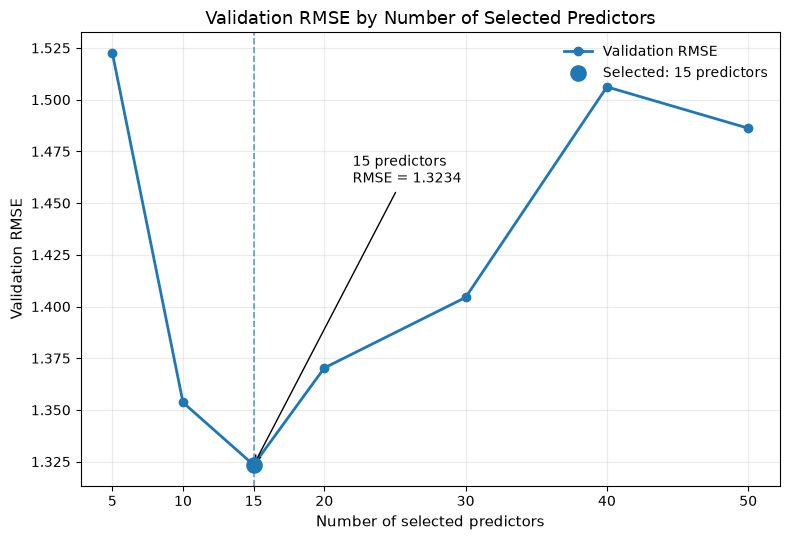


PUBLICATION FIGURE SAVED
Selected predictor count: 15
Validation RMSE: 1.3234
Figure saved to: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\figures\validation_rmse_feature_count.png


: 

In [ ]:
# ============================================================
# PUBLICATION FIGURE
# VALIDATION RMSE VS NUMBER OF SELECTED PREDICTORS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------------------------
# 1. LOCATE PROJECT ROOT
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the Eswatini_Water_Stress_ML project root."
    )

print("Project root:", PROJECT_ROOT)


# ------------------------------------------------------------
# 2. PREPARE VALIDATION RESULTS
# ------------------------------------------------------------

feature_validation = pd.DataFrame({
    "Features": [
        5,
        10,
        15,
        20,
        30,
        40,
        50
    ],
    "RMSE": [
        1.5226,
        1.3536,
        1.3234,
        1.3703,
        1.4044,
        1.5062,
        1.4862
    ]
})

optimal_features = 15
optimal_rmse = 1.3234


# ------------------------------------------------------------
# 3. CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.plot(
    feature_validation["Features"],
    feature_validation["RMSE"],
    marker="o",
    linewidth=2,
    label="Validation RMSE"
)


# ------------------------------------------------------------
# 4. HIGHLIGHT SELECTED FEATURE COUNT
# ------------------------------------------------------------

ax.scatter(
    optimal_features,
    optimal_rmse,
    s=120,
    zorder=5,
    label="Selected: 15 predictors"
)

ax.axvline(
    x=optimal_features,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7
)

ax.annotate(
    "15 predictors\nRMSE = 1.3234",
    xy=(
        optimal_features,
        optimal_rmse
    ),
    xytext=(
        22,
        1.46
    ),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10
)


# ------------------------------------------------------------
# 5. FORMAT FIGURE
# ------------------------------------------------------------

ax.set_xlabel(
    "Number of selected predictors",
    fontsize=11
)

ax.set_ylabel(
    "Validation RMSE",
    fontsize=11
)

ax.set_title(
    "Validation RMSE by Number of Selected Predictors",
    fontsize=13
)

ax.set_xticks(
    feature_validation["Features"]
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

fig.tight_layout()


# ------------------------------------------------------------
# 6. SAVE PUBLICATION-QUALITY FIGURE
# ------------------------------------------------------------

output_path = (
    PROJECT_ROOT
    / "figures"
    / "validation_rmse_feature_count.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. CONFIRM OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PUBLICATION FIGURE SAVED")
print("=" * 70)

print(
    "Selected predictor count:",
    optimal_features
)

print(
    "Validation RMSE:",
    optimal_rmse
)

print(
    "Figure saved to:",
    output_path
)